In [498]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
import joblib


In [500]:
!pip install kaggle

In [501]:
import kagglehub

In [502]:
# 2. Load Dataset
path = kagglehub.dataset_download("alanjo/gpu-benchmarks")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\veray\.cache\kagglehub\datasets\alanjo\gpu-benchmarks\versions\30


In [503]:
data_csv = path + "/GPU_benchmarks_v7.csv"
print(data_csv)
df = pd.read_csv(data_csv)

C:\Users\veray\.cache\kagglehub\datasets\alanjo\gpu-benchmarks\versions\30/GPU_benchmarks_v7.csv


In [504]:
data = pd.read_csv(data_csv)
data.head()

,gpuName,G3Dmark,G2Dmark,price,gpuValue,TDP,powerPerformance,testDate,category
0,GeForce RTX 3090 Ti,29094,1117,2099.99,13.85,450.0,64.65,2022,Unknown
1,GeForce RTX 3080 Ti,26887,1031,1199.99,22.41,350.0,76.82,2021,Desktop
2,GeForce RTX 3090,26395,999,1749.99,15.08,350.0,75.41,2020,Desktop
3,Radeon RX 6900 XT,25458,1102,1120.31,22.72,300.0,84.86,2020,Desktop
4,GeForce RTX 3080,24853,1003,999.00,24.88,320.0,77.66,2020,Desktop


In [505]:
# 3. Initial Inspection
print(df.head())
print(df.info())
print(df.describe())

               gpuName  G3Dmark  G2Dmark    price  gpuValue    TDP  \
0  GeForce RTX 3090 Ti    29094     1117  2099.99     13.85  450.0   
1  GeForce RTX 3080 Ti    26887     1031  1199.99     22.41  350.0   
2     GeForce RTX 3090    26395      999  1749.99     15.08  350.0   
3    Radeon RX 6900 XT    25458     1102  1120.31     22.72  300.0   
4     GeForce RTX 3080    24853     1003   999.00     24.88  320.0   

   powerPerformance  testDate category  
0             64.65      2022  Unknown  
1             76.82      2021  Desktop  
2             75.41      2020  Desktop  
3             84.86      2020  Desktop  
4             77.66      2020  Desktop  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2317 entries, 0 to 2316
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gpuName           2317 non-null   object 
 1   G3Dmark           2317 non-null   int64  
 2   G2Dmark           2317 non-null   

In [506]:
data = data.dropna()  # Optional: remove missing data
data = data.drop(columns=["Unnamed: 0", "GPU", "Release Date"], errors="ignore")

In [507]:
# 4. Data Cleaning
# Drop rows with missing target (G3Dmark)
df = df.dropna(subset=['G3Dmark'])

In [508]:
data.columns

Index(['gpuName', 'G3Dmark', 'G2Dmark', 'price', 'gpuValue', 'TDP',
       'powerPerformance', 'testDate', 'category'],
      dtype='object')

In [509]:
# Fill missing numeric values with median
num_cols = df.select_dtypes(include=[np.number]).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())


In [512]:
# Drop duplicates
df = df.drop_duplicates()

In [513]:
# 5. Feature Engineering
# Create Performance-per-Watt feature
if 'G3Dmark' in df.columns and 'TDP' in df.columns:
    df['performancePerWatt'] = df['G3Dmark'] / df['TDP'].replace(0, np.nan)

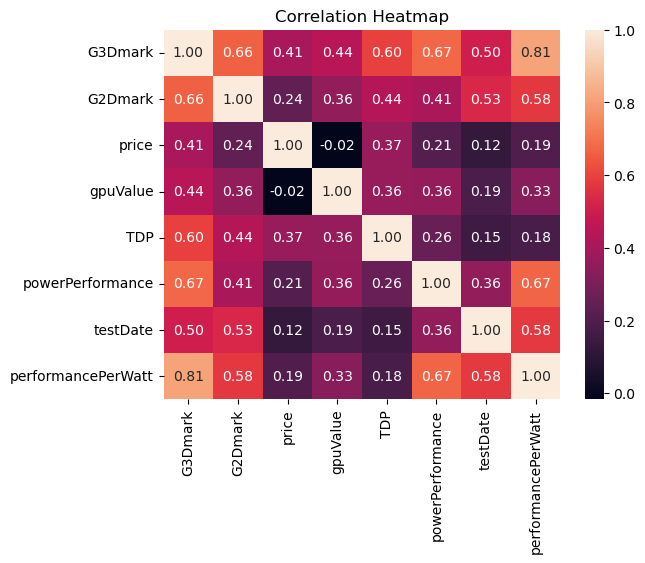

In [522]:
# 6. EDA (just a few examples)
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

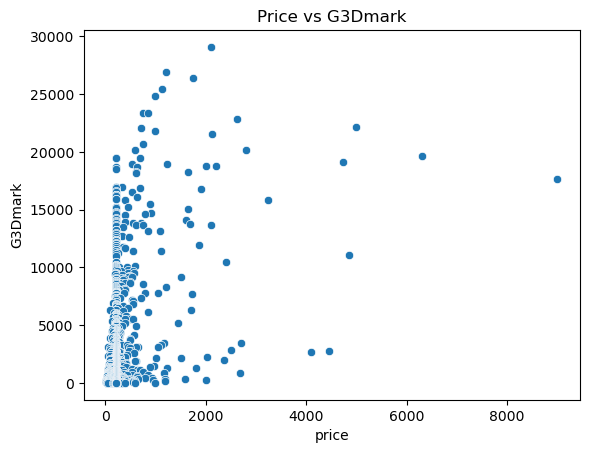

In [525]:
sns.scatterplot(x='price', y='G3Dmark', data=df)
plt.title("Price vs G3Dmark")
plt.show()

In [527]:
# 7. Data Preprocessing
X = df[['price', 'TDP', 'powerPerformance', 'gpuValue', 'performancePerWatt']]
y = df['G3Dmark']

In [530]:
# Handle missing engineered values
X = X.copy()
X.fillna(X.median(), inplace=True)

In [532]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [534]:
# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [536]:
# 8. Model Training
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Support Vector Regressor": SVR()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} - MSE: {mse:.2f}, R^2: {r2:.2f}")

Linear Regression - MSE: 1904615.66, R^2: 0.83
Random Forest - MSE: 195715.51, R^2: 0.98
Support Vector Regressor - MSE: 12731794.97, R^2: -0.11


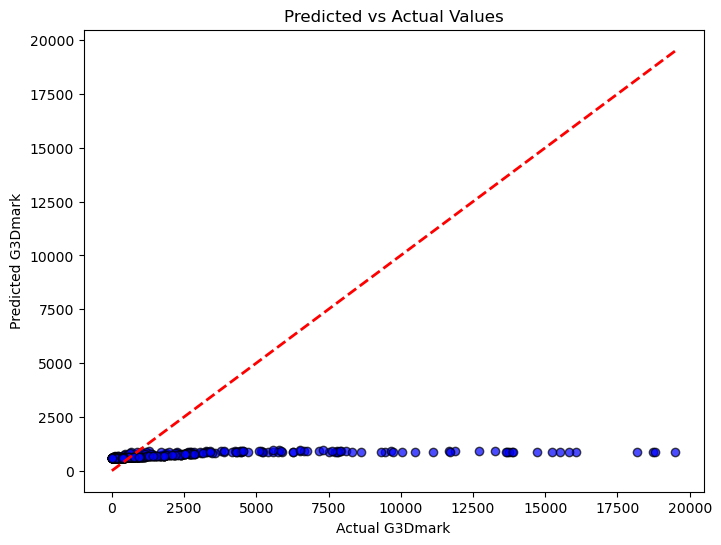

In [537]:
# Predicted vs Actual values plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual G3Dmark')
plt.ylabel('Predicted G3Dmark')
plt.show()

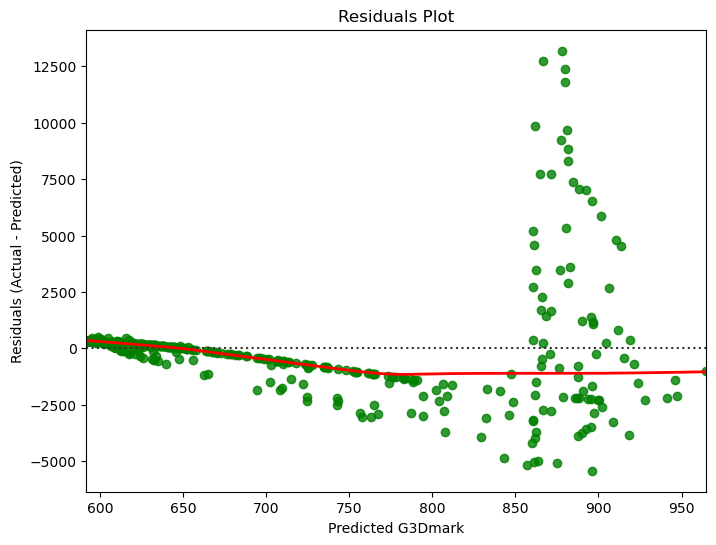

In [538]:
# Residuals plot
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True, color='green', line_kws={'color': 'red', 'lw': 2})
plt.title('Residuals Plot')
plt.xlabel('Predicted G3Dmark')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

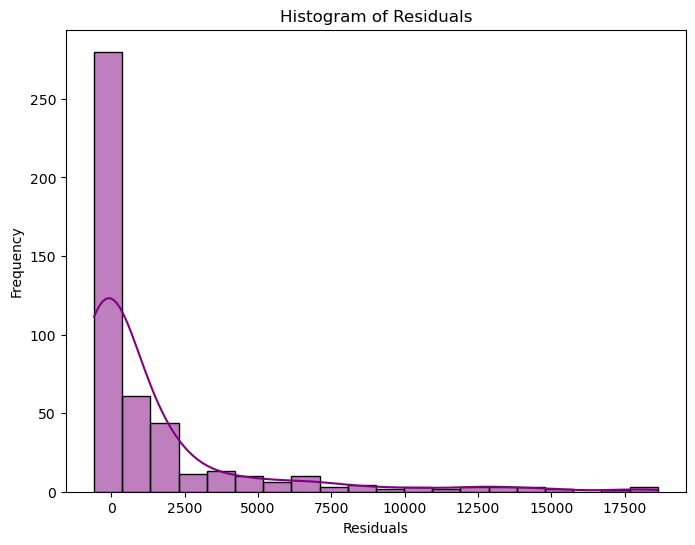

In [540]:
# Optional: Histogram of residuals
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='purple', bins=20)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

In [543]:
# 9. Hyperparameter Tuning (Random Forest example)
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2')
grid.fit(X_train_scaled, y_train)

print("\nBest Random Forest Parameters:", grid.best_params_)
y_pred_best = grid.predict(X_test_scaled)
print("Tuned Random Forest R^2:", r2_score(y_test, y_pred_best))


Best Random Forest Parameters: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Random Forest R^2: 0.9831374941531694


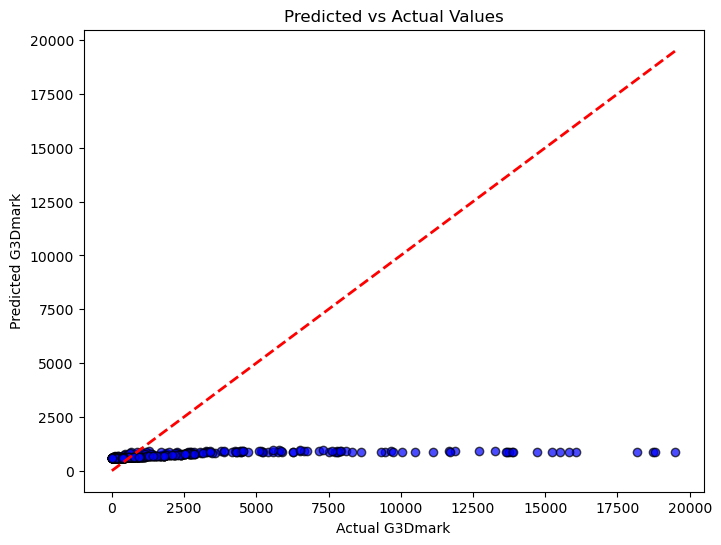

In [545]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', edgecolor='k', alpha=0.7)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title('Predicted vs Actual Values')
plt.xlabel('Actual G3Dmark')
plt.ylabel('Predicted G3Dmark')
plt.show()

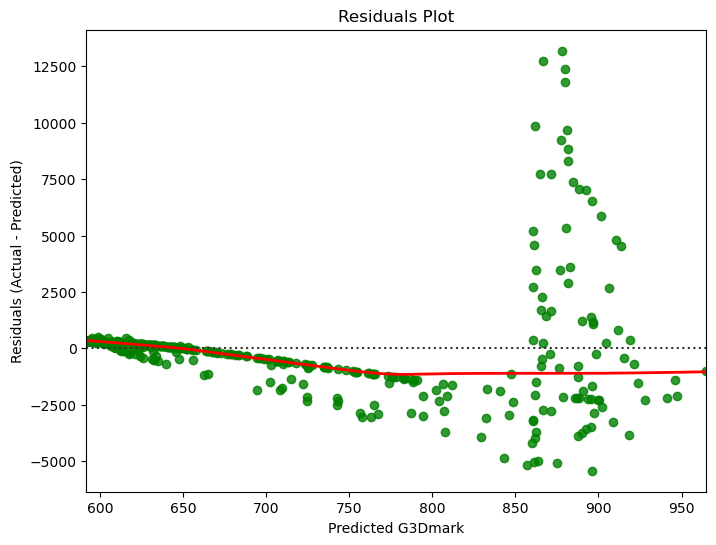

In [546]:
residuals = y_test - y_pred
plt.figure(figsize=(8, 6))
sns.residplot(x=y_pred, y=residuals, lowess=True, color='green', line_kws={'color': 'red', 'lw': 2})
plt.title('Residuals Plot')
plt.xlabel('Predicted G3Dmark')
plt.ylabel('Residuals (Actual - Predicted)')
plt.show()

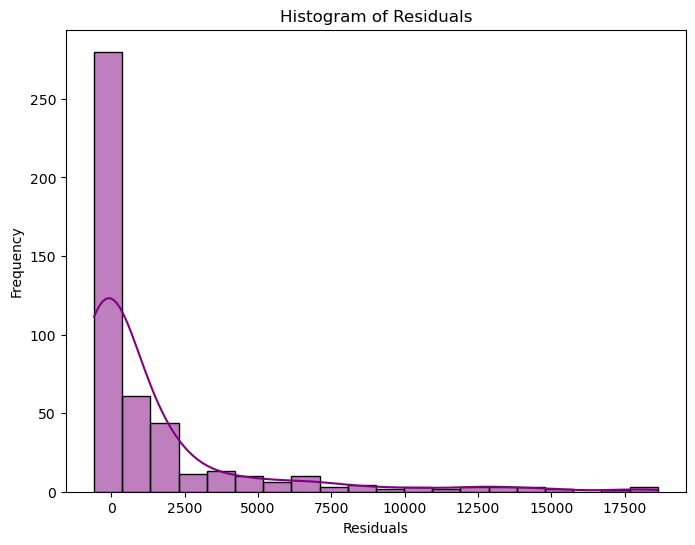

In [547]:
plt.figure(figsize=(8, 6))
sns.histplot(residuals, kde=True, color='purple', bins=20)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

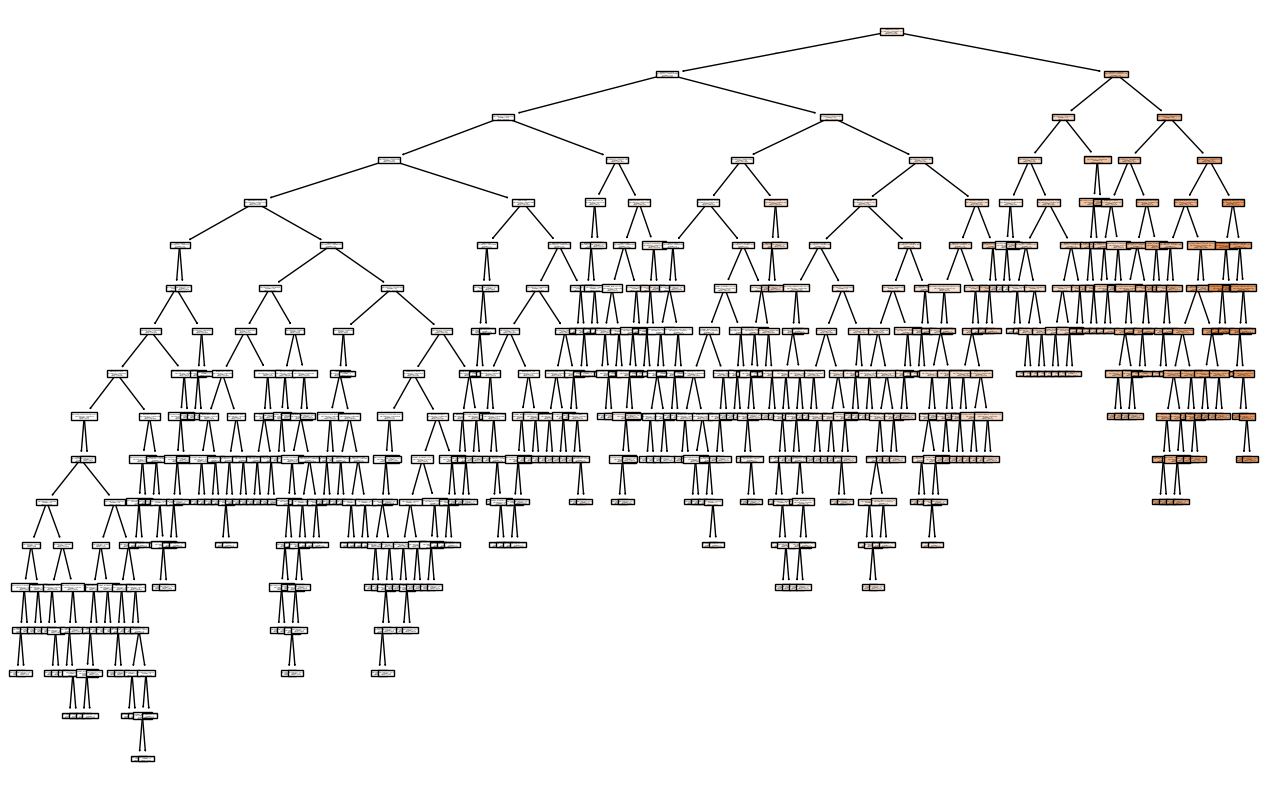

|--- G2Dmark <= 751.00
|   |--- G2Dmark <= 414.50
|   |   |--- powerPerformance <= 27.51
|   |   |   |--- G2Dmark <= 338.00
|   |   |   |   |--- gpuValue <= 2.74
|   |   |   |   |   |--- TDP <= 185.00
|   |   |   |   |   |   |--- price <= 592.49
|   |   |   |   |   |   |   |--- TDP <= 72.50
|   |   |   |   |   |   |   |   |--- gpuValue <= 2.14
|   |   |   |   |   |   |   |   |   |--- gpuName_GeForce GT 705 <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- TDP <= 31.25
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |   |   |   |   |   |   |--- TDP >  31.25
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 7
|   |   |   |   |   |   |   |   |   |--- gpuName_GeForce GT 705 >  0.50
|   |   |   |   |   |   |   |   |   |   |--- value: [355.00]
|   |   |   |   |   |   |   |   |--- gpuValue >  2.14
|   |   |   |   |   |   |   |   |   |--- price <= 114.50
|   |   |   |   |   |   |   |   |   |   |--- gpuName_RADEON HD 6350 

In [548]:
X = data.drop(columns=["G3Dmark"])
y = data["G3Dmark"]

# Handle non-numeric data (e.g., 'gpuName', 'category', 'testDate')
X = pd.get_dummies(X, drop_first=True)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=45)

# Train the model
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Visualize the tree
plt.figure(figsize=(16, 10))
plot_tree(model, filled=True, feature_names=X.columns)
plt.show()

# Print tree rules
tree_rules = export_text(model, feature_names=list(X.columns))
print(tree_rules)

# Evaluate performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

In [549]:
best_model = grid.best_estimator_  # save the tuned model
joblib.dump(best_model, 'gpu_benchmark_model.pkl')  # save the model to a file
print("\nBest Model Saved Successfully.")


Best Model Saved Successfully.


In [550]:
model = joblib.load('gpu_benchmark_model.pkl')

In [551]:
# Example new data
new_data = pd.DataFrame({
    'price': [350, 500],  # example price values for new GPU data
    'TDP': [150, 180],  # example TDP values for new GPU data
    'powerPerformance': [15, 18],  # example power performance values
    'gpuValue': [0.9, 1.2],  # example gpuValue for new data
    'performancePerWatt': [2.4, 2.8]  # example performancePerWatt values
})

In [552]:
# Preprocess the new data
new_data_scaled = scaler.transform(new_data)  #scale the new data using the same scaler

In [553]:
# Make predictions
predictions = model.predict(new_data_scaled)  # predict using the loaded model
print("\nPredictions for New Data:", predictions)  #display the predictions


Predictions for New Data: [337.26139803 414.46551058]


In [554]:
# 12. Conclusion
print("\nProject Complete: Best model identified, evaluated, and saved.")


Project Complete: Best model identified, evaluated, and saved.
